<a href="https://colab.research.google.com/github/fablan-code/portfolio/blob/main/electricity_demand_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

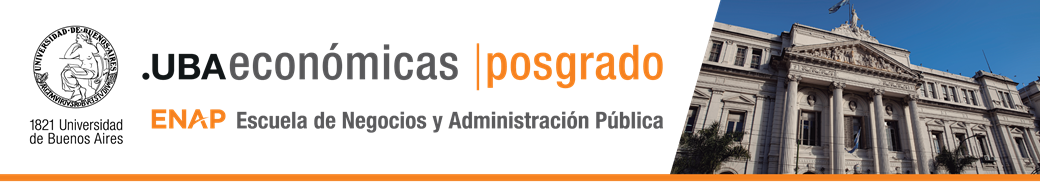

## **Metodologías Avanzados de Aprendizaje Automático**
# REDES RECURRENTES

**Docentes: Roberto Abalde, Mónica Cantoni**

**Alumno: Facundo Matías Blanco**


## Dataset: Open Power System Data - Francia

**Objetivo:**
Seleccionar un conjunto de datos de demanda de energía eléctrica de un país.  Puede ser univariada o multivariada.
Tratar de aumentar los datos con datos económicos o de clime.
Crear un red neuronal que utilice LSTM para pronosticar la demanda futura. Optimizar la red.
Analizar la performance del modelo desarrollado.

**Métricas:** MAE y RMSE


## Instalación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import tensorflow as tf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA


## Carga del dataset

In [ ]:
df = pd.read_csv("/content/time_series_60min_singleindex_filtered.csv", sep=",")
df.head(20)

,utc_timestamp,cet_cest_timestamp,FR_load_actual_entsoe_transparency,FR_load_forecast_entsoe_transparency,FR_solar_generation_actual,FR_wind_onshore_generation_actual
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,69773.0,69750.0,NaN,1464.0
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,66417.0,66300.0,NaN,1543.0
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,64182.0,63250.0,NaN,1579.0
5,2015-01-01T04:00:00Z,2015-01-01T05:00:00+0100,63859.0,61500.0,NaN,1482.0
6,2015-01-01T05:00:00Z,2015-01-01T06:00:00+0100,63921.0,60850.0,NaN,1387.0
7,2015-01-01T06:00:00Z,2015-01-01T07:00:00+0100,64117.0,60450.0,NaN,1583.0
8,2015-01-01T07:00:00Z,2015-01-01T08:00:00+0100,63861.0,60150.0,NaN,1814.0
9,2015-01-01T08:00:00Z,2015-01-01T09:00:00+0100,64277.0,59950.0,385.0,1936.0


<Axes: >

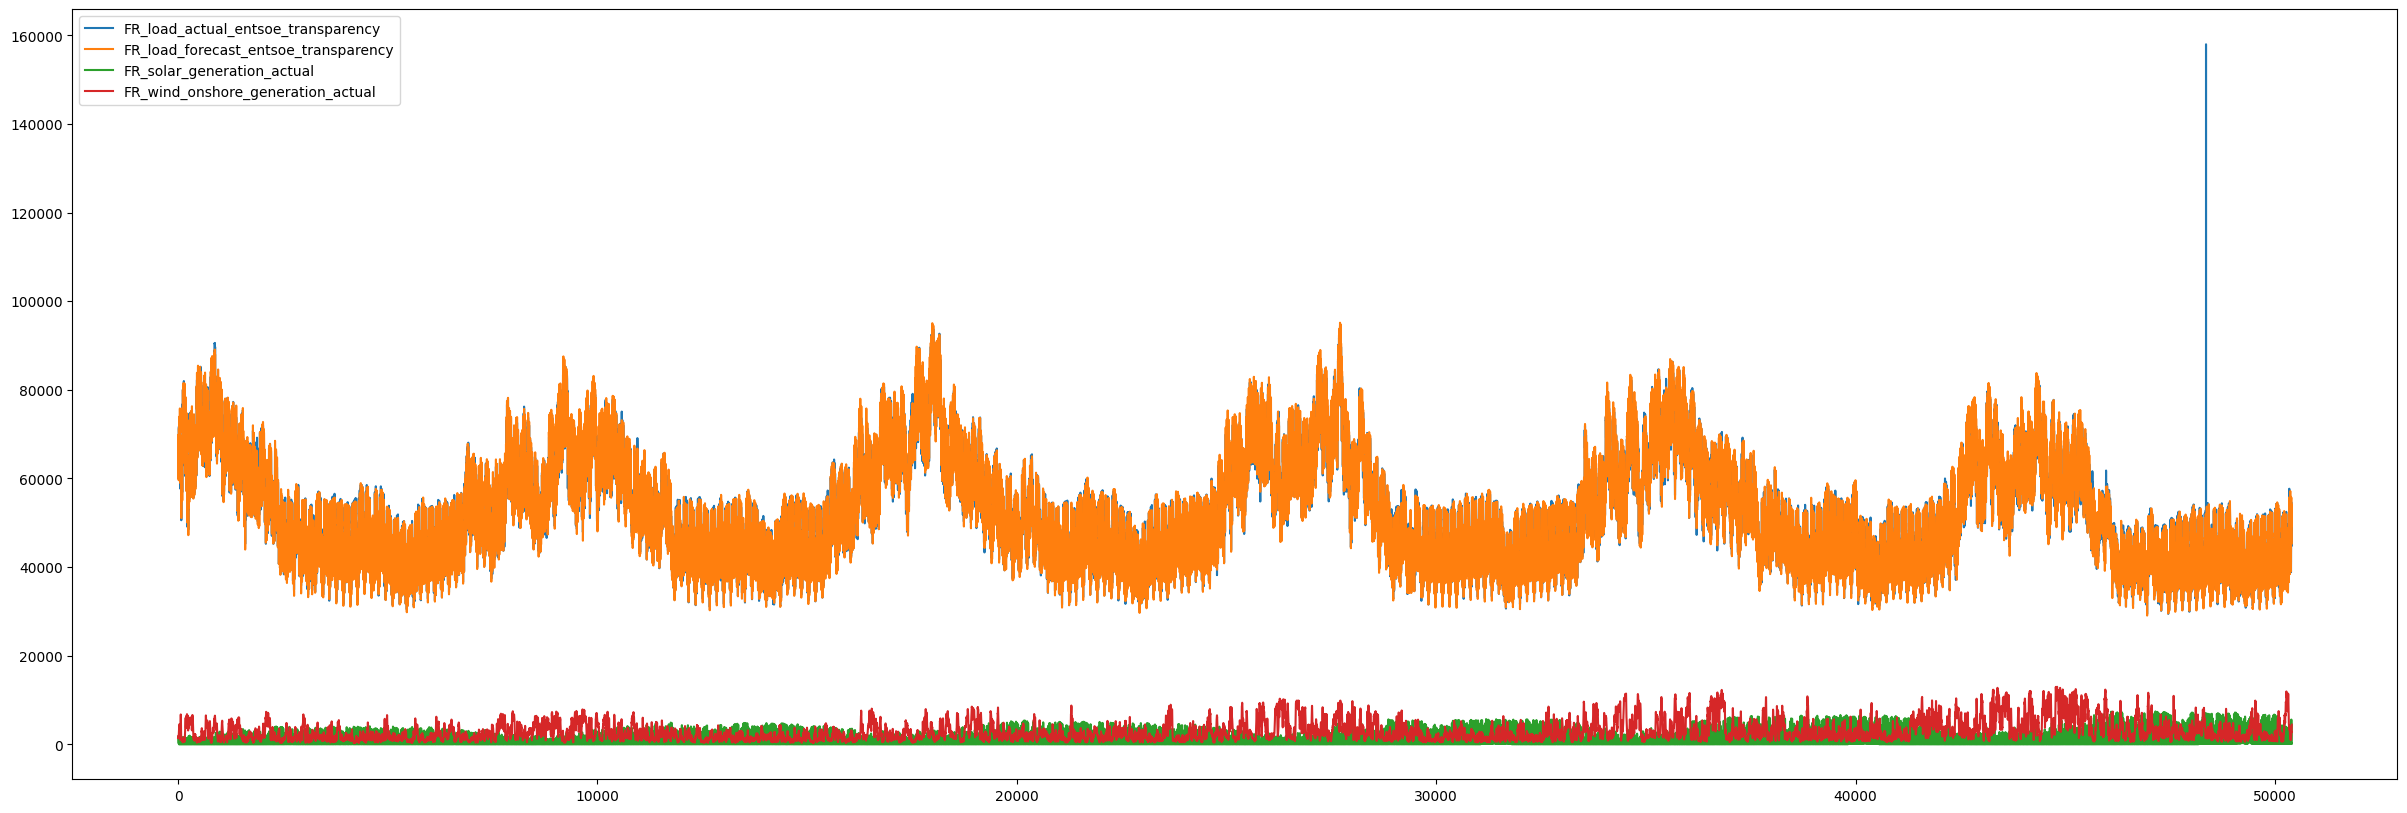

In [ ]:
df.plot.line(figsize=(30, 10))

##Preprocesamiento de datos

In [ ]:
#Drop de columnas irrelevantes
df = df.drop(["utc_timestamp","FR_solar_generation_actual","FR_wind_onshore_generation_actual","FR_load_forecast_entsoe_transparency"], axis=1)
df.head()

,cet_cest_timestamp,FR_load_actual_entsoe_transparency
0,2015-01-01T00:00:00+0100,NaN
1,2015-01-01T01:00:00+0100,NaN
2,2015-01-01T02:00:00+0100,69773.0
3,2015-01-01T03:00:00+0100,66417.0
4,2015-01-01T04:00:00+0100,64182.0


In [ ]:
# Parsear timestamp local
df['cet_cest_timestamp'] = pd.to_datetime(df['cet_cest_timestamp'], utc=True)
df = df.set_index('cet_cest_timestamp')
df.index = df.index.tz_localize(None)  # sacamos timezone para simplificar

# Reset del index y renombre de la columna a 'Día y hora'
df = df.reset_index()
df = df.rename(columns={'cet_cest_timestamp': 'Día y hora'})

In [ ]:
# Renombrar para simplificar
df = df.rename(columns={
    'FR_load_actual_entsoe_transparency':   'demanda'
})

print(df.shape)
print(df.head())

(50401, 2)
           Día y hora  demanda
0 2014-12-31 23:00:00      NaN
1 2015-01-01 00:00:00      NaN
2 2015-01-01 01:00:00  69773.0
3 2015-01-01 02:00:00  66417.0
4 2015-01-01 03:00:00  64182.0


In [ ]:
df.dtypes

,0
Día y hora,datetime64[ns]
demanda,float64


In [ ]:
# Tratamiento de nulos
print(df.isnull().sum())
df['demanda'] = df['demanda'].interpolate(method='linear')
print(df.isnull().sum())

Día y hora     0
demanda       44
dtype: int64
Día y hora    0
demanda       2
dtype: int64


In [ ]:
print(df[df['demanda'].isna()])

           Día y hora  demanda
0 2014-12-31 23:00:00      NaN
1 2015-01-01 00:00:00      NaN


In [ ]:
df = df.dropna()
print(df.isnull().sum())

Día y hora    0
demanda       0
dtype: int64


In [ ]:
# Guardo min y max antes de normalizar
dem_min = df['demanda'].min()
dem_max = df['demanda'].max()

In [ ]:
df['demanda'] = (df['demanda'] - df['demanda'].min()) / (df['demanda'].max() - df['demanda'].min())
df.head()

,Día y hora,demanda
2,2015-01-01 01:00:00,0.313953
3,2015-01-01 02:00:00,0.287857
4,2015-01-01 03:00:00,0.270478
5,2015-01-01 04:00:00,0.267966
6,2015-01-01 05:00:00,0.268448


# LSTM

##División train test

In [ ]:
# divido en entrenamiento y prueba

train = df[df['Día y hora'] < '2019-01-01']
test  = df[df['Día y hora'] >= '2019-01-01']
print(train.shape, test.shape)

(35063, 2) (15336, 2)


In [ ]:
window_size = 48
cols = ['demanda']

X_train = pd.concat([
    pd.concat([train[c].shift(w, fill_value=0) for w in range(1, window_size+1)],
              axis=1, keys=[f"{c}_{w}" for w in range(1, window_size+1)])
    for c in cols], axis=1)

X_test = pd.concat([
    pd.concat([test[c].shift(w, fill_value=0) for w in range(1, window_size+1)],
              axis=1, keys=[f"{c}_{w}" for w in range(1, window_size+1)])
    for c in cols], axis=1)

y_train = train['demanda']
y_test  = test['demanda']

print(X_train.shape)  # debería ser (n, 96, 1) → 48 pasos x 2 variables

(35063, 48)


In [ ]:
X_train = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.values.reshape((X_test.shape[0], X_test.shape[1], 1))

print(X_train.shape)
print(X_test.shape)

(35063, 48, 1)
(15336, 48, 1)


##Modelado

In [ ]:
# modelado
model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=[window_size, len(cols)]),
    tf.keras.layers.LSTM(24),
    tf.keras.layers.Dense(1),
])

model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()

model.compile(loss="mean_squared_error", optimizer="adam", metrics=["mean_squared_error"])
history = model.fit(X_train, y_train, epochs=32, batch_size=10, verbose=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24)             │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,521 (9.85 KB)

 Trainable params: 2,521 (9.85 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/32
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 0.0014 - mean_squared_error: 0.0014
Epoch 2/32
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 8.5768e-04 - mean_squared_error: 8.5768e-04
Epoch 3/32
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 7.9514e-04 - mean_squared_error: 7.9514e-04
Epoch 4/32
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 6.6285e-04 - mean_squared_error: 6.6285e-04
Epoch 5/32
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5.3457e-04 - mean_squared_error: 5.3457e-04
Epoch 6/32
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 4.0729e-04 - mean_squared_error: 4.0729e-04
Epoch 7/32
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 3.0470e-04 - mean_squared_error: 3.0470e-04
Epoch 8/32
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 2.7521e-04 - mean_squared_error: 2.7521e-04
Epoch 9/32
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 2.2715e-04 - mean_squared_error: 2.2715e-04
Epoch 10/32
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 23

##Predicciones


In [ ]:
# Predicciones
train_predict = model.predict(X_train).flatten()
test_predict  = model.predict(X_test).flatten()

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


##Métricas

In [ ]:
# Métricas
mae  = np.mean(np.abs(test_predict - y_test))
rmse = np.sqrt(np.mean((test_predict - y_test)**2))

In [ ]:
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE:  0.0055
RMSE: 0.0107


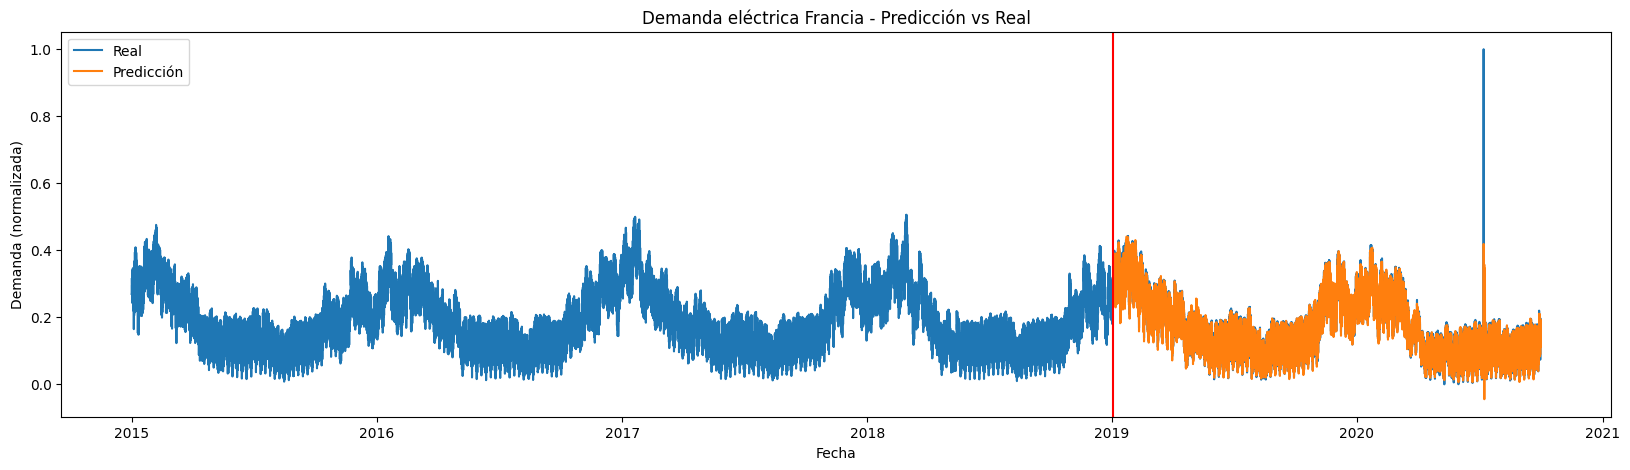

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(df['Día y hora'], df['demanda'], label='Real')
plt.plot(test['Día y hora'].values[window_size:], test_predict[window_size:], label='Predicción')
plt.axvline(x=test['Día y hora'].iloc[window_size], color='r')
plt.xlabel('Fecha')
plt.ylabel('Demanda (normalizada)')
plt.title('Demanda eléctrica Francia - Predicción vs Real')
plt.legend()
plt.show()

# ARIMA

In [ ]:
# Resampleo
df_mensual = df.copy()
df_mensual = df_mensual.set_index('Día y hora')

# Desnormalizar usando los valores guardados antes de normalizar
df_mensual['demanda'] = df_mensual['demanda'] * (dem_max - dem_min) + dem_min

# Resampleo mensual (promedio)
df_mensual = df_mensual['demanda'].resample('MS').mean()

print(df_mensual.shape)
print(df_mensual.head())

(69,)
Día y hora
2015-01-01    69521.224764
2015-02-01    71374.474702
2015-03-01    60630.245968
2015-04-01    50608.841667
2015-05-01    45213.907258
Freq: MS, Name: demanda, dtype: float64


In [ ]:
# División train/test (70/30)
train = df_mensual[df_mensual.index < '2019-01-01']
test  = df_mensual[df_mensual.index >= '2019-01-01']

print(f"Train: {len(train)} obs | {train.index[0].date()} → {train.index[-1].date()}")
print(f"Test:  {len(test)} obs  | {test.index[0].date()} → {test.index[-1].date()}")

Train: 48 obs | 2015-01-01 → 2018-12-01
Test:  21 obs  | 2019-01-01 → 2020-09-01


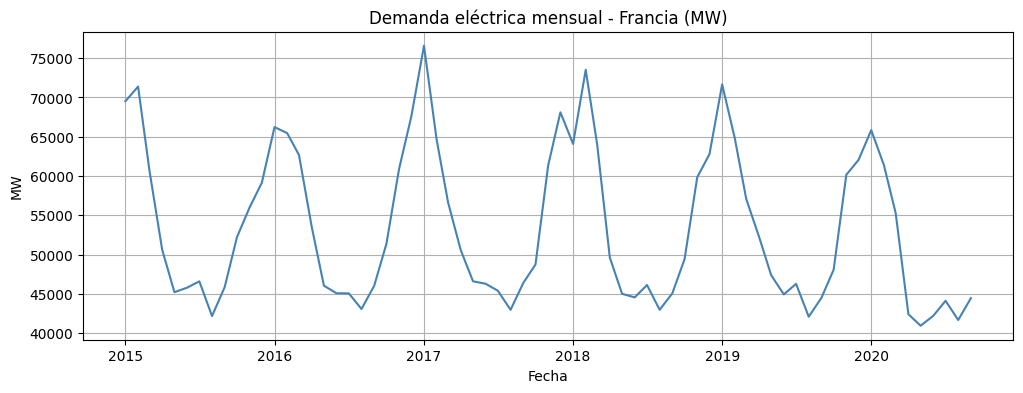

In [ ]:
# Gráfico de la serie
plt.figure(figsize=(12, 4))
plt.plot(df_mensual, color='steelblue', linewidth=1.5)
plt.title('Demanda eléctrica mensual - Francia (MW)')
plt.xlabel('Fecha')
plt.ylabel('MW')
plt.grid(True)
plt.show()


In [ ]:
# Test ADF
result = adfuller(df_mensual.dropna(), maxlag=5, autolag=None)
print("Augmented Dickey-Fuller Test")
print(f"Dickey-Fuller = {result[0]:.4f}, Lag order = {result[2]}, p-value = {result[1]:.5f}")
print(f"Number of observations used = {result[3]}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")
if result[1] > 0.05:
    print("La serie NO es estacionaria (no rechazamos H0)\n")
else:
    print("La serie es estacionaria (rechazamos H0)\n")

Augmented Dickey-Fuller Test
Dickey-Fuller = -6.2008, Lag order = 5, p-value = 0.00000
Number of observations used = 63
Critical Values:
   1%: -3.5387
   5%: -2.9086
   10%: -2.5919
La serie es estacionaria (rechazamos H0)



In [ ]:
# Test KPSS
stat, p_value, lags, critical_values = kpss(df_mensual, regression='ct', nlags='auto')
print("KPSS Test Summary")
print(f"KPSS Statistic: {stat:.4f}")
print(f"p-value: {p_value:.5f}")
print(f"Lags utilizados: {lags}")
print("Valores críticos:")
for key, value in critical_values.items():
    print(f"  {key}: {value:.4f}")
if p_value < 0.05:
    print("La serie NO es estacionaria (rechazamos H0)")
else:
    print("La serie es estacionaria (no rechazamos H0)")

KPSS Test Summary
KPSS Statistic: 0.0355
p-value: 0.10000
Lags utilizados: 4
Valores críticos:
  10%: 0.1190
  5%: 0.1460
  2.5%: 0.1760
  1%: 0.2160
La serie es estacionaria (no rechazamos H0)


/tmp/ipykernel_39559/1126234944.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, lags, critical_values = kpss(df_mensual, regression='ct', nlags='auto')


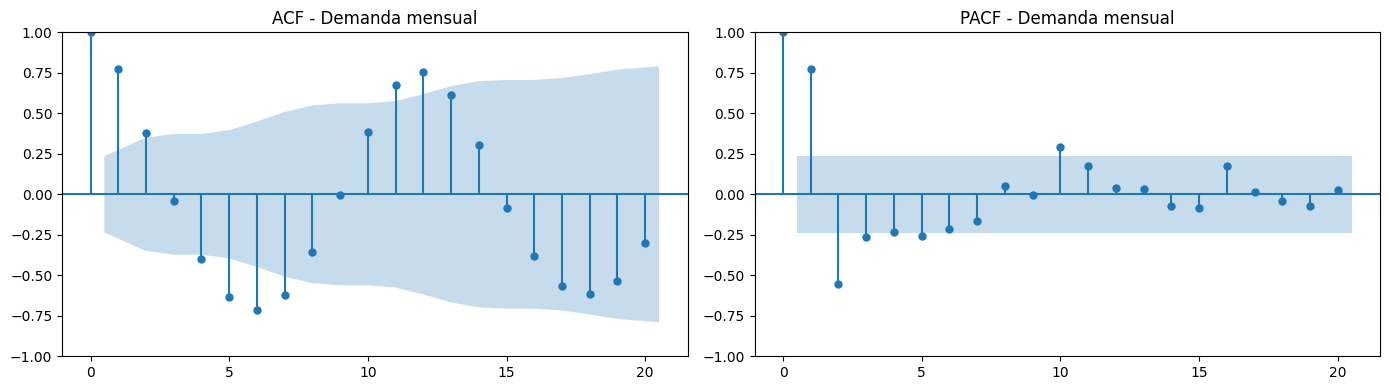

In [ ]:
# ACF y PACF de la serie en niveles
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df_mensual, lags=20, ax=axes[0])
axes[0].set_title('ACF - Demanda mensual')

plot_pacf(df_mensual, lags=20, method='ywm', ax=axes[1])
axes[1].set_title('PACF - Demanda mensual')

plt.tight_layout()
plt.show()

In [ ]:
# Candidatos ARIMA
candidatos = [(1,0,0), (0,0,1), (1,0,1)]
resultados = {}

for order in candidatos:
    model = ARIMA(train, order=order)
    fit = model.fit()
    resultados[order] = {'aic': fit.aic, 'bic': fit.bic, 'model': fit}
    print(f"ARIMA{order} -> AIC: {fit.aic:.2f}, BIC: {fit.bic:.2f}")

ARIMA(1, 0, 0) -> AIC: 978.31, BIC: 983.92
ARIMA(0, 0, 1) -> AIC: 987.52, BIC: 993.14
ARIMA(1, 0, 1) -> AIC: 968.52, BIC: 976.00


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Residuos del modelo seleccionado
residuos = resultados[(1,0,1)]['model'].resid

# Test de Ljung-Box
lb_test = acorr_ljungbox(residuos, lags=[10, 20, 30], return_df=True)
print(lb_test)

      lb_stat  lb_pvalue
10  19.624571   0.033010
20  51.536560   0.000133
30  76.169379   0.000007


In [ ]:
from sklearn.metrics import mean_squared_error

modelo_arima = resultados[(1,0,1)]['model']

# RMSE train
rmse_arima_train = np.sqrt(mean_squared_error(train, modelo_arima.fittedvalues))

# RMSE test
pred_arima = modelo_arima.forecast(steps=21)
rmse_arima_test = np.sqrt(mean_squared_error(test, pred_arima))

print(f"RMSE Train ARIMA: {rmse_arima_train:.2f}")
print(f"RMSE Test  ARIMA: {rmse_arima_test:.2f}")

RMSE Train ARIMA: 5582.16
RMSE Test  ARIMA: 9261.39


#SARIMA

In [ ]:
# Candidatos SARIMA (order, seasonal_order)
candidatos_sarima = [
    ((1,0,1), (1,0,0,12)),
    ((1,0,1), (0,0,1,12)),
    ((1,0,1), (1,0,1,12)),
    ((1,0,0), (1,0,1,12)),
]

resultados_sarima = {}

for order, seasonal in candidatos_sarima:
    model = SARIMAX(train, order=order, seasonal_order=seasonal)
    fit = model.fit(disp=False)
    rmse_train = np.sqrt(mean_squared_error(train, fit.fittedvalues))
    pred = fit.forecast(steps=21)
    pred.index = test.index
    rmse_test = np.sqrt(mean_squared_error(test, pred))
    resultados_sarima[(order, seasonal)] = {
        'aic': fit.aic, 'bic': fit.bic,
        'rmse_train': rmse_train, 'rmse_test': rmse_test,
        'model': fit, 'pred': pred
    }
    print(f"SARIMA{order}x{seasonal} -> AIC: {fit.aic:.2f} | BIC: {fit.bic:.2f} | RMSE Train: {rmse_train:.2f} | RMSE Test: {rmse_test:.2f}")

# Mejor por AIC
mejor_key = min(resultados_sarima, key=lambda k: resultados_sarima[k]['aic'])
print(f"\nMejor modelo por AIC: SARIMA{mejor_key[0]}x{mejor_key[1]}")
fit_sarima = resultados_sarima[mejor_key]['model']
pred_sarima = resultados_sarima[mejor_key]['pred']
rmse_sarima_train = resultados_sarima[mejor_key]['rmse_train']
rmse_sarima_test  = resultados_sarima[mejor_key]['rmse_test']

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


SARIMA(1, 0, 1)x(1, 0, 0, 12) -> AIC: 976.56 | BIC: 984.05 | RMSE Train: 11753.29 | RMSE Test: 4603.14
SARIMA(1, 0, 1)x(0, 0, 1, 12) -> AIC: 974.66 | BIC: 982.14 | RMSE Train: 11349.91 | RMSE Test: 7457.58


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


SARIMA(1, 0, 1)x(1, 0, 1, 12) -> AIC: 962.19 | BIC: 971.55 | RMSE Train: 11095.28 | RMSE Test: 2887.01


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


SARIMA(1, 0, 0)x(1, 0, 1, 12) -> AIC: 961.42 | BIC: 968.90 | RMSE Train: 11034.31 | RMSE Test: 2676.38

Mejor modelo por AIC: SARIMA(1, 0, 0)x(1, 0, 1, 12)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE Train SARIMA: 11095.28
RMSE Test  SARIMA: 2887.01


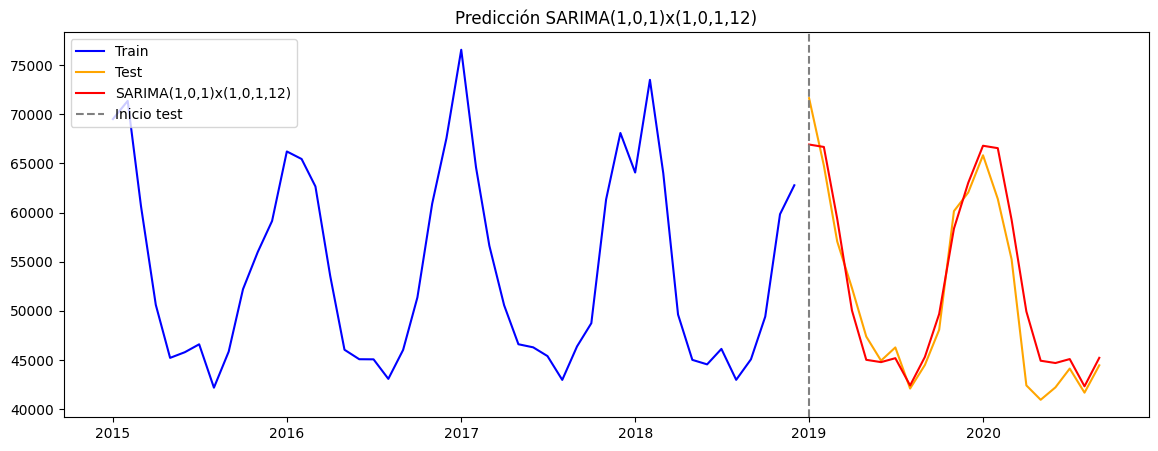

In [ ]:
# Modelo seleccionado: SARIMA(1,0,1)x(1,0,1,12) - segundo mejor AIC, por parsimonia
mejor_key = ((1,0,1), (1,0,1,12))
fit_sarima = resultados_sarima[mejor_key]['model']
pred_sarima = resultados_sarima[mejor_key]['pred']
rmse_sarima_train = resultados_sarima[mejor_key]['rmse_train']
rmse_sarima_test  = resultados_sarima[mejor_key]['rmse_test']

print(f"RMSE Train SARIMA: {rmse_sarima_train:.2f}")
print(f"RMSE Test  SARIMA: {rmse_sarima_test:.2f}")

# Gráfico
plt.figure(figsize=(14, 5))
plt.plot(train, label='Train', color='blue')
plt.plot(test, label='Test', color='orange')
plt.plot(pred_sarima, label='SARIMA(1,0,1)x(1,0,1,12)', color='red')
plt.axvline(x=test.index[0], color='gray', linestyle='--', label='Inicio test')
plt.title('Predicción SARIMA(1,0,1)x(1,0,1,12)')
plt.legend(loc='upper left')
plt.show()

# Prophet

In [ ]:
from prophet import Prophet

# Preparación de los datos para Prophet
prophet_train = train.reset_index()
prophet_train.columns = ['ds', 'y']


In [ ]:
# Fit
m = Prophet(interval_width=0.95)
m.fit(prophet_train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
# Predicciones
future = m.make_future_dataframe(periods=21, freq='MS')
forecast = m.predict(future)

# Extraer predicciones train y test
pred_prophet_train = forecast.set_index('ds')['yhat'].head(48)
pred_prophet_train.index = train.index

pred_prophet = forecast.set_index('ds')['yhat'].tail(21)
pred_prophet.index = test.index

RMSE Train Prophet: 2166.43
RMSE Test  Prophet: 4196.49


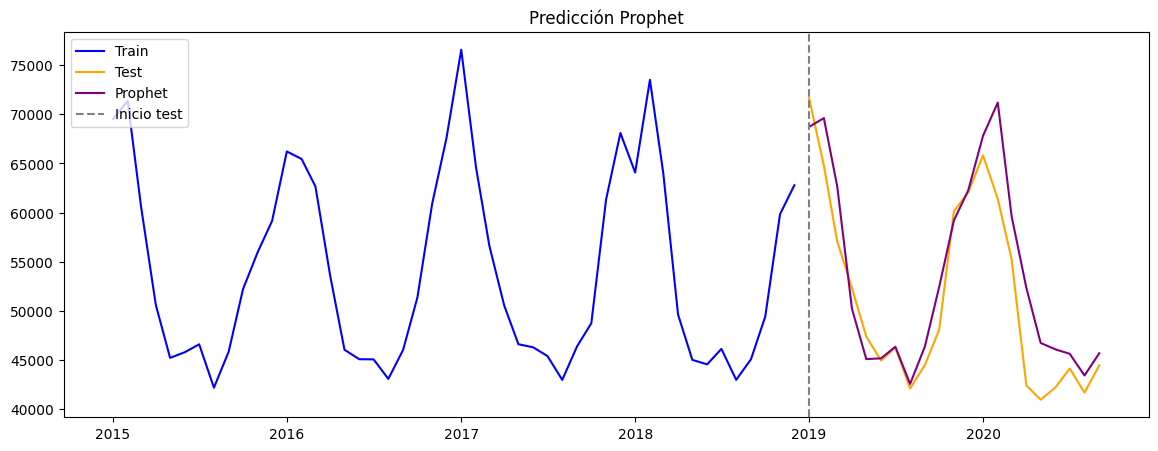

In [ ]:
# RMSE
rmse_prophet_train = np.sqrt(mean_squared_error(train, pred_prophet_train))
rmse_prophet_test  = np.sqrt(mean_squared_error(test, pred_prophet))
print(f"RMSE Train Prophet: {rmse_prophet_train:.2f}")
print(f"RMSE Test  Prophet: {rmse_prophet_test:.2f}")

# Gráfico
plt.figure(figsize=(14, 5))
plt.plot(train, label='Train', color='blue')
plt.plot(test, label='Test', color='orange')
plt.plot(pred_prophet, label='Prophet', color='purple')
plt.axvline(x=test.index[0], color='gray', linestyle='--', label='Inicio test')
plt.title('Predicción Prophet')
plt.legend(loc='upper left')
plt.show()

#Comparación gráfica

In [ ]:
# RMSE - desnormalizados

rmse_train = np.sqrt(np.mean((train_predict - y_train)**2))
rmse_lstm_train_mw = rmse_train * (dem_max - dem_min)

print(f"RMSE Train LSTM (normalizado): {rmse_train:.4f}")
print(f"RMSE Train LSTM (MW):          {rmse_lstm_train_mw:.2f}")


RMSE Train LSTM (normalizado): 0.0076
RMSE Train LSTM (MW):          976.27


In [ ]:
# LSTM - desnormalizar métricas a escala MW
lstm_rmse_norm = 0.0104

rmse_lstm_test = lstm_rmse_norm * (dem_max - dem_min)

print(f"RMSE Test LSTM: {rmse_lstm_test:.2f} MW")

RMSE Test LSTM: 1337.46 MW


In [ ]:
# Tabla resumen comparativa actualizada con LSTM train
print(f"{'Modelo':<30} {'RMSE Train':>12} {'RMSE Test':>12}")
print("-" * 55)
print(f"{'ARIMA(1,0,1)':<30} {rmse_arima_train:>12.2f} {rmse_arima_test:>12.2f}")
print(f"{'SARIMA(1,0,1)x(1,0,1,12)':<30} {rmse_sarima_train:>12.2f} {rmse_sarima_test:>12.2f}")
print(f"{'Prophet':<30} {rmse_prophet_train:>12.2f} {rmse_prophet_test:>12.2f}")
print(f"{'LSTM':<30} {rmse_lstm_train_mw:>12.2f} {rmse_lstm_test:>12.2f}")

Modelo                           RMSE Train    RMSE Test
-------------------------------------------------------
ARIMA(1,0,1)                        5582.16      9261.39
SARIMA(1,0,1)x(1,0,1,12)           11095.28      2887.01
Prophet                             2166.43      4196.49
LSTM                                 976.27      1337.46


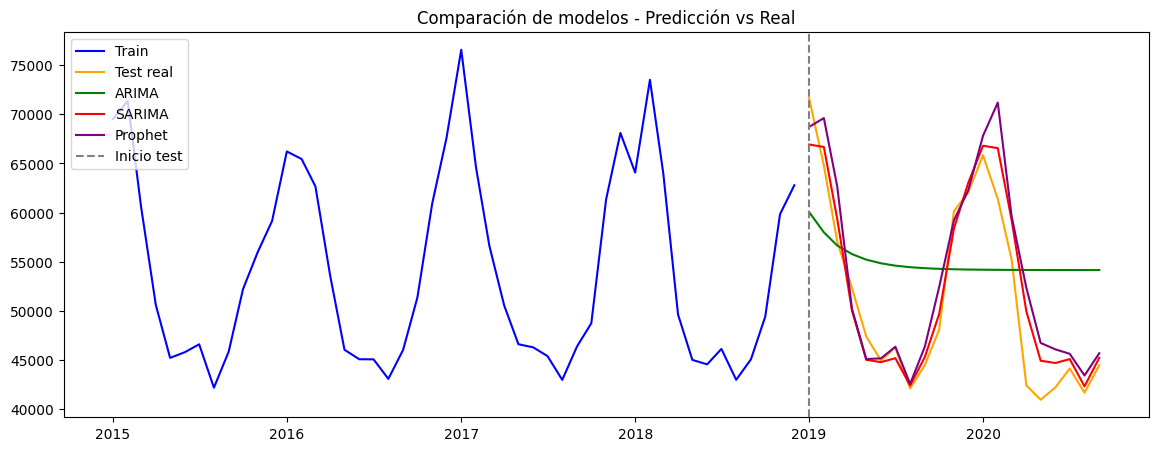

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(train, label='Train', color='blue')
plt.plot(test, label='Test real', color='orange')
plt.plot(pred_arima, label='ARIMA', color='green')
plt.plot(pred_sarima, label='SARIMA', color='red')
plt.plot(pred_prophet, label='Prophet', color='purple')
plt.axvline(x=test.index[0], color='gray', linestyle='--', label='Inicio test')
plt.title('Comparación de modelos - Predicción vs Real')
plt.legend(loc='upper left')
plt.show()
